In [1]:
# import the required packages
import pandas as pd
import numpy as np

# Import the function from the module
from func_collect_data import collect_data

In [2]:
my_conn = "sqlite:///../wk8/bike_orders_database.sqlite"

In [3]:
# Use the function just like any other function
df = collect_data(conn_string = my_conn)

# Copying vs Assigning

In [13]:
# 1. Create a sample DataFrame
data = {'Name': ['Alice', 'Bob'], 'Age': [20, 25]}
df_sample = pd.DataFrame(data)
df_sample

,Name,Age
0,Alice,20
1,Bob,25


In [14]:
# 2. ASSIGNMENT (The "Reference")
# df_ref points to the same object in memory as df
df_ref = df_sample 
df_ref

,Name,Age
0,Alice,20
1,Bob,25


In [15]:
# 3. COPYING (The "Deep Clone")
# df_copy creates an entirely new object in memory
df_copy = df_sample.copy()
df_copy

,Name,Age
0,Alice,20
1,Bob,25


In [16]:
# --- Now, let's modify the Age of both ---

# Changing df_ref affects the original df!
df_ref.loc[0, 'Age'] = 99 
df_ref

,Name,Age
0,Alice,99
1,Bob,25


In [17]:
# Changing df_copy does NOT affect the original df
df_copy.loc[1, 'Age'] = 100
df_copy

,Name,Age
0,Alice,20
1,Bob,100


In [19]:
print("Original DataFrame (Notice how row 0 changed but row 1 did not):")
df_sample

Original DataFrame (Notice how row 0 changed but row 1 did not):


,Name,Age
0,Alice,99
1,Bob,25


# 5. Grouping
**Summarizing (Aggregating)**. Applying a summary function that takes a Series and returns a *single value*. Example: np.mean().

*Summarizing* differs from *transformations* like np.log() and pd.qcut(), which return a Series of the same length as the input.

In [ ]:
# Aggregations (No Grouping)
# df.sum() is shorthand for df.aggregate(np.sum)
# df.sum() # This will throw an error
# df.agg(np.sum) # This will throw an error
df.sum(numeric_only=True)

df['total_price'].sum()
df[['total_price']].sum() # np.sum() returns a single values that represents the addition of the incoming Series
df[['total_price']].sum().to_frame() # Turn into a data frame

# df.agg(), df.aggregate(). These are the same.
# Advantages:
# 1. We can target columns
# 2. We can apply more than one aggregation function
df.select_dtypes(include=['number'])
df.select_dtypes(include=['number']).agg(np.sum)
df.select_dtypes(include=['number']) \
    .agg([np.sum, np.mean, np.std])

df.agg(
    {
        'quantity': np.sum,
        'total_price': np.sum
    }
)

df.agg(
    {
        'quantity': np.sum,
        'total_price': [np.sum, np.mean]
    }
)

In [ ]:
# Common summary functions
# df.value_counts(): Get the frequency of values.  This is technically a "grouped summary"
df['model'].value_counts() # Series
df[['model']].value_counts() # Data frame. We get the same results.  The difference here is that we can add more cols
df[['model', 'category_1']].value_counts() # Two different indexes

# df.nunique(): Get the number of unique values
df.nunique()

# df.isna()> Returns True/False as to whether or not values are missing.
# Can be combined with sum() to aggregate the quantity of missing values.
# Boolean Summation. False is interpreted as 0 and True is interpreted as 1.
# The Sum function adds the 0's and 1's to get a missing count.
df.isna()
df.isna().sum()

df.std(numeric_only=True)

df1 = df.select_dtypes(include='number')
df1.aggregate([np.mean, np.std])

## 5.1 Groupby + Agg
Grouping is one of the most important skills in data science.  It is the ability to *segment your data by a group or category*, and apply functions to those groups independently. The *most commom* combination is groupby and aggregate/

In [ ]:
# df.groupby(): Creates a grouped data frame that tracks and applies functions group-wise
df.groupby(['city'])  # we get a df groupby object
df.groupby(['city']).sum(numeric_only=True)
df.groupby(['city', 'state']).sum(numeric_only=True)

# dict(total_price = np.sum). This is a sophisticated way to tell pandas which calculation to perform on which column.
# Why a dictionary? A dictionary allows us to map column names to specific functions. If we want to sum total_price but calculate the average of quantity, we could do it in one single line:
# agg(dict(total_price=np.sum, quantity=np.mean))
# Dictionary casting with dict().  For casting an assignment expression to a dictionary.
df.groupby(['city', 'state']).agg(dict(total_price = np.sum))

# Let's unpack the above expression
df \
    .groupby(['city', 'state']) \
    .agg(
        dict(total_price = np.sum)
    )

# The next expressions are equivalent
dict(total_price = np.sum)
{'total_price': np.sum}

df \
    .groupby(['city', 'state']) \
    .agg(
        dict(
            total_price = np.sum,
            quantity = np.mean
        )
    )

# Multi-level indexes
df \
    .groupby(['city', 'state']) \
    .agg(
        dict(
            total_price = np.sum,
            quantity = [np.mean, np.sum]
        )
    )

In [ ]:
# Get the sum and median by groups
# Follow this process when doing a groupby:
# 1. Isolate just the columns needed for the analysis
# 2. Group By the grouping column(s).
# 3. Apply the aggreation.
# 4. Reset the index if needed

df[['category_1', 'category_2', 'total_price']] # Isolate the required columns, don't use the entire dataset

df[['category_1', 'category_2', 'total_price']] \
    .groupby(['category_1', 'category_2']) # By running this code, we have a dataframe groupby object

df[['category_1', 'category_2', 'total_price']] \
    .groupby(['category_1', 'category_2']) \
    .agg([np.sum, np.median])

# Sometimes we want to move the indexes back into the dataframe
# df.reset_index(): Returns the grouped row index as columns. 
df[['category_1', 'category_2', 'total_price']] \
    .groupby(['category_1', 'category_2']) \
    .agg([np.sum, np.median]) \
    .reset_index()

In [ ]:
summary_df_1 = df[['category_1', 'category_2', 'total_price']] \
    .groupby(['category_1', 'category_2']) \
    .agg([np.sum, np.median]) \
    .reset_index()

In [ ]:
# Apply Summary functions to specific columns
df[['category_1', 'category_2', 'total_price', 'quantity']]

df[['category_1', 'category_2', 'total_price', 'quantity']] \
    .groupby(['category_1', 'category_2'])

df[['category_1', 'category_2', 'total_price', 'quantity']] \
    .groupby(['category_1', 'category_2']) \
    .agg(
        {
            'quantity': np.sum,
            'total_price': np.sum
        }
    )

df[['category_1', 'category_2', 'total_price', 'quantity']] \
    .groupby(['category_1', 'category_2']) \
    .agg(
        {
            'quantity': np.sum,
            'total_price': np.sum
        }
    ) \
    .reset_index()

In [ ]:
summary_df_2 = df[['category_1', 'category_2', 'total_price', 'quantity']] \
    .groupby(['category_1', 'category_2']) \
    .agg(
        {
            'quantity': np.sum,
            'total_price': np.sum
        }
    ) \
    .reset_index()

### Grouped Transformations

Transformations are the application of functions to groups that return the same number of rows as the original.

**An example is a Standardization Transformation (Scale & Center):**
Standardization removes the mean (centers) and divides the series by the standard deviation (scales).

* **Application:** We can apply the Standardization transformation group-wise to more easily compare time series data when it's on the same scale.

*Note: Group-wise scaling is a powerful technique for normalizing features across different categories or time-based cohorts.*

In [27]:
# 5.3 Groupby + Transforms (Apply function)
# Note: Groupby + Assign does not work. No assign method for groups
df[['category_2', 'order_date', 'total_price', 'quantity']] # grab the columns we need.  order_date will be the index

# Time series analysis on a weekly basis
# We are moving order_date to the index. This is mandatory for time-series resampling in Pandas.
df[['category_2', 'order_date', 'total_price', 'quantity']] \
    .set_index('order_date')

# we get a groupby object
df[['category_2', 'order_date', 'total_price', 'quantity']] \
    .set_index('order_date') \
    .groupby('category_2')

# Resample() is just another way to group. We are grouping on a Weekly Group in addition to by Category_2.
# Then, we will tell our aggregation to apply the sum() to these groups.
# .resample('W'): It looks at the time-indexed data within each of those category buckets and aggregates it into weekly chunks.
# We get a DatetimeIndexResamplerGroupby object. The object we are holding is a "lazy" object. It has not actually performed a calculation yet; it has simply prepared the framework for you to perform an aggregation.
# To see the actual result, we must chain an aggregation function like .sum(), .mean(), or .count()
df[['category_2', 'order_date', 'total_price', 'quantity']] \
    .set_index('order_date') \
    .groupby('category_2') \
    .resample('W')

df[['category_2', 'order_date', 'total_price', 'quantity']] \
    .set_index('order_date') \
    .groupby('category_2') \
    .resample('W') \
    .agg(np.sum)

# We haven't done any transformations. Reset the index
df[['category_2', 'order_date', 'total_price', 'quantity']] \
    .set_index('order_date') \
    .groupby('category_2') \
    .resample('W') \
    .agg(np.sum) \
    .reset_index()

,category_2,order_date,total_price,quantity
0,Cross Country Race,2011-01-16,61750,8
1,Cross Country Race,2011-01-23,25050,4
2,Cross Country Race,2011-01-30,56860,14
3,Cross Country Race,2011-02-06,8740,3
4,Cross Country Race,2011-02-13,78070,15
...,...,...,...,...
2324,Triathalon,2015-11-29,21250,6
2325,Triathalon,2015-12-06,5850,3
2326,Triathalon,2015-12-13,0,0
2327,Triathalon,2015-12-20,10200,2


In [28]:
summary_df_3 = df[['category_2', 'order_date', 'total_price', 'quantity']] \
    .set_index('order_date') \
    .groupby('category_2') \
    .resample('W') \
    .agg(np.sum) \
    .reset_index()

summary_df_3

,category_2,order_date,total_price,quantity
0,Cross Country Race,2011-01-16,61750,8
1,Cross Country Race,2011-01-23,25050,4
2,Cross Country Race,2011-01-30,56860,14
3,Cross Country Race,2011-02-06,8740,3
4,Cross Country Race,2011-02-13,78070,15
...,...,...,...,...
2324,Triathalon,2015-11-29,21250,6
2325,Triathalon,2015-12-06,5850,3
2326,Triathalon,2015-12-13,0,0
2327,Triathalon,2015-12-20,10200,2


<Axes: xlabel='order_date'>

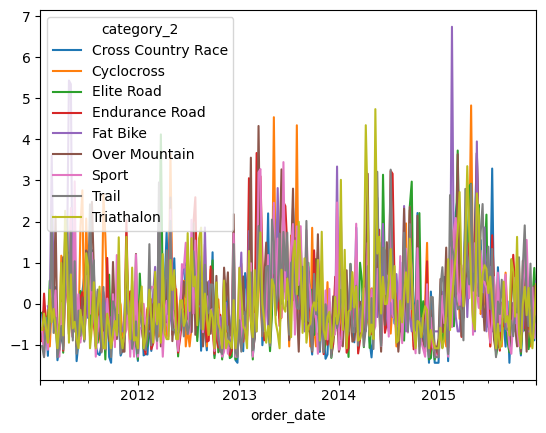

In [37]:
# Scale price 
# df.GroupBy.apply(): Applies a function (typically a lambda) group-wise.
# A very flexible function that can summarize or transform
summary_df_3 \
    .set_index('order_date')

summary_df_3 \
    .set_index('order_date') \
    .groupby('category_2')

summary_df_3 \
    .set_index('order_date') \
    .groupby('category_2') \
    .apply(lambda x: x.total_price)

# Centering: When we remove the average
summary_df_3 \
    .set_index('order_date') \
    .groupby('category_2') \
    .apply(lambda x: x.total_price - x.total_price.mean())

# Scaling: When we divide by the standard deviation
summary_df_3 \
    .set_index('order_date') \
    .groupby('category_2') \
    .apply(lambda x: (x.total_price - x.total_price.mean()) / x.total_price.std())

# Reset the index
summary_df_3 \
    .set_index('order_date') \
    .groupby('category_2') \
    .apply(lambda x: (x.total_price - x.total_price.mean()) / x.total_price.std()) \
    .reset_index()

# The .pivot() method is a powerful tool for reshaping our data. It takes our data from a "long" format (where categories are listed vertically) 
# and transforms it into a "wide" format (where categories are spread out into columns), making it much easier to compare different segments side-by-side.
# index = 'order_date': This becomes the new "row identifier." Pandas will look at every unique date in your data and create one row for each.
# columns = 'category_2': This tells Pandas to take the unique values in the category_2 column and turn them into individual column headers in the new table.
#values = 'total_price': This tells Pandas which data should fill the intersection of those new rows and columns.
summary_df_3 \
    .set_index('order_date') \
    .groupby('category_2') \
    .apply(lambda x: (x.total_price - x.total_price.mean()) / x.total_price.std()) \
    .reset_index() \
    .pivot(
        index = 'order_date',
        columns = 'category_2',
        values = 'total_price'
    )

# All time series overlap because they were scaled
summary_df_3 \
    .set_index('order_date') \
    .groupby('category_2') \
    .apply(lambda x: (x.total_price - x.total_price.mean()) / x.total_price.std()) \
    .reset_index() \
    .pivot(
        index = 'order_date',
        columns = 'category_2',
        values = 'total_price'
    ) \
    .plot()

In [42]:
# Scale price and quantity columns by groups
summary_df_3 \
    .set_index(['order_date','category_2']) 

# category_2 is an index now. We can still group by this column
summary_df_3 \
    .set_index(['order_date','category_2']) \
    .groupby('category_2')

# Remember that "x" is our data frame in our lambda function. When we run apply, it will cycle through
# each column in the data frame applying our transformation
# Group-wise scaling
summary_df_3 \
    .set_index(['order_date','category_2']) \
    .groupby('category_2') \
    .apply(lambda x: (x - x.mean()) / x.std())

summary_df_3 \
    .set_index(['order_date','category_2']) \
    .groupby('category_2') \
    .apply(lambda x: (x - x.mean()) / x.std()) \
    .reset_index()

total_price  quantity
category_2         order_date category_2                               
Cross Country Race 2011-01-16 Cross Country Race    -0.241538 -0.641784
                   2011-01-23 Cross Country Race    -0.952038 -1.054502
                   2011-01-30 Cross Country Race    -0.336207 -0.022707
                   2011-02-06 Cross Country Race    -1.267795 -1.157681
                   2011-02-13 Cross Country Race     0.074411  0.080472
...                                                       ...       ...
Triathalon         2015-11-29 Triathalon             0.387521  0.415754
                   2015-12-06 Triathalon            -0.678455 -0.381878
                   2015-12-13 Triathalon            -1.083388 -1.179510
                   2015-12-20 Triathalon            -0.377352 -0.647755
                   2015-12-27 Triathalon             0.477506  0.415754

[2329 rows x 2 columns]

In [46]:
# 5.4 Groupby + Filter (Apply).  Row filter or slicing
df.tail() # We slice the last 5 rows of the data frame

# we want to slice by group. We get the last 5 observations of each group
summary_df_3 \
    .groupby('category_2') \
    .tail(5)  

# We want to filter something in the middle.
summary_df_3 \
    .groupby('category_2') \
    .apply(lambda x: x.iloc[10:20])

order_date  total_price  quantity
category_2                                               
Cross Country Race 10   2011-03-27        28990         6
                   11   2011-04-03        51860        11
                   12   2011-04-10        85910        18
                   13   2011-04-17       138230        20
                   14   2011-04-24       138350        27
...                            ...          ...       ...
Triathalon         2085 2011-05-01        25950         8
                   2086 2011-05-08         7000         1
                   2087 2011-05-15         9300         4
                   2088 2011-05-22         3200         1
                   2089 2011-05-29            0         0

[90 rows x 3 columns]

# 6. Joins

In [47]:
orderlines_df = pd.read_excel("orderlines.xlsx")
bikes_df = pd.read_excel("bikes.xlsx")

C:\Users\Admin\miniconda3\envs\dab\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [51]:
# Merge (Joining)
# We join data frames to get data from one data frame into another, where there is a PK relationship.
# Most of the time we use LEFT or INNER JOIN, so this is what we will focus on
# pd.merge(): Merges two data frames using primary keys.
# default is how = 'inner'
pd.merge(
    left = orderlines_df,
    right = bikes_df,
    left_on = 'product.id',
    right_on = 'bike.id',
    how = 'left'
)

,Unnamed: 0,order.id,order.line,order.date,customer.id,product.id,quantity,bike.id,model,description,price
0,1,1,1,2011-01-07,2,48,1,48,Jekyll Carbon 2,Mountain - Over Mountain - Carbon,6070
1,2,1,2,2011-01-07,2,52,1,52,Trigger Carbon 2,Mountain - Over Mountain - Carbon,5970
2,3,2,1,2011-01-10,10,76,1,76,Beast of the East 1,Mountain - Trail - Aluminum,2770
3,4,2,2,2011-01-10,10,52,1,52,Trigger Carbon 2,Mountain - Over Mountain - Carbon,5970
4,5,3,1,2011-01-10,6,2,1,2,Supersix Evo Hi-Mod Team,Road - Elite Road - Carbon,10660
...,...,...,...,...,...,...,...,...,...,...,...
15639,15640,2000,4,2015-12-25,15,14,1,14,CAAD Disc Ultegra,Road - Elite Road - Aluminum,2660
15640,15641,2000,5,2015-12-25,15,90,1,90,Trail 2,Mountain - Sport - Aluminum,1350
15641,15642,2000,6,2015-12-25,15,17,1,17,CAAD12 105,Road - Elite Road - Aluminum,1680
15642,15643,2000,7,2015-12-25,15,70,1,70,F-Si Carbon 4,Mountain - Cross Country Race - Carbon,2880
